## 1. Cài đặt thư viện

In [ ]:
!pip install contractions transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00


## 2. Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, log_loss)

# TensorFlow / Keras (LSTM)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping

# PyTorch & HuggingFace (BERT)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Corrected import for AdamW, using torch.optim
from tqdm import tqdm

print(f'TensorFlow: {tf.__version__}')
print(f'PyTorch   : {torch.__version__}')
print(f'GPU (TF)  : {tf.config.list_physical_devices("GPU")}')
print(f'GPU (PT)  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name  : {torch.cuda.get_device_name(0)}')

TensorFlow: 2.19.0
PyTorch   : 2.10.0+cu128
GPU (TF)  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (PT)  : True
GPU name  : Tesla T4


## 3. Tải dữ liệu WELFake Dataset

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Data_TL'
df=pd.read_csv('preprocessed_welfake.csv')

# ═══════════════════════════════════════════════════════════
# SAMPLING DATASET: Giảm xuống 22,054 mẫu (cân bằng với tiếng Việt)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("📊 DATASET GỐC (WELFake)")
print("="*55)
print(f"Tổng mẫu: {len(df):,}")
print(f"Tin thật (0): {(df['label']==0).sum():,} ({(df['label']==0).sum()/len(df)*100:.1f}%)")
print(f"Tin giả (1): {(df['label']==1).sum():,} ({(df['label']==1).sum()/len(df)*100:.1f}%)")

# Sampling để có tỷ lệ giống file tiếng Việt
TARGET_TOTAL = 22054
TARGET_REAL = 15886  # 72%
TARGET_FAKE = 6168   # 28%

print("\n" + "="*55)
print(f"🎯 SAMPLING XUỐNG {TARGET_TOTAL:,} MẪU")
print("="*55)

df_real = df[df['label'] == 0].sample(n=TARGET_REAL, random_state=42)
df_fake = df[df['label'] == 1].sample(n=TARGET_FAKE, random_state=42)

df = pd.concat([df_real, df_fake], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Đã sampling:")
print(f"   Tổng mẫu    : {len(df):,}")
print(f"   Tin thật (0): {(df['label']==0).sum():,}  ({(df['label']==0).sum()/len(df)*100:.1f}%)")
print(f"   Tin giả (1) : {(df['label']==1).sum():,}  ({(df['label']==1).sum()/len(df)*100:.1f}%)")
print("="*55)
print("✅ Dataset đã cân bằng với file tiếng Việt!")
print("="*55)

df.head(10)

Mounted at /content/drive
/content/drive/MyDrive/Data_TL

📊 DATASET GỐC (WELFake)
Tổng mẫu: 71,537
Tin thật (0): 35,028 (49.0%)
Tin giả (1): 36,509 (51.0%)

🎯 SAMPLING XUỐNG 22,054 MẪU
✅ Đã sampling:
   Tổng mẫu    : 22,054
   Tin thật (0): 15,886  (72.0%)
   Tin giả (1) : 6,168  (28.0%)
✅ Dataset đã cân bằng với file tiếng Việt!


,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title
0,Special Report: 'Treacherous shenanigans' - Th...,HARARE (Reuters) - Inside State House in Harar...,0,en,341,0.029374,79,0.357143,"['special', 'report', 'treacherous', 'shenanig...","['rare', 'renter', 'inside', 'state', 'house',...",81,14775,14856,"['special', 'report', 'treacherous', 'shenanig...",Special Report: 'Treacherous shenanigans' - Th...
1,"Warren Buffett, in Annual Letter, Offers Hymn ...","Warren E. Buffett, the billionaire investor, o...",0,en,82,0.020506,47,0.118182,"['warren', 'buffet', 'annual', 'letter', 'offe...","['warren', 'e', 'buffet', 'millionaire', 'inve...",82,3755,3837,"['warren', 'buffet', 'annual', 'letter', 'offe...","Warren Buffett, in Annual Letter, Offers Hymn ..."
2,Exclusive: GOP campaigns plot revolt against RNC,"Killing Obama administration rules, dismantlin...",0,ca,3,0.025641,0,0.000000,[],"['kill', 'drama', 'administration', 'rule', 'd...",48,117,165,"[]['kill', 'drama', 'administration', 'rule', ...",Exclusive: GOP campaigns plot revolt against R...
3,"Trump hotels reach deal with unions, ending la...",(Reuters) - Hotels in Las Vegas and Washington...,0,en,57,0.039348,11,0.000000,"['tramp', 'hotel', 'reach', 'deal', 'union', '...","['renter', 'hotel', 'las', 'begin', 'washingto...",61,2516,2577,"['tramp', 'hotel', 'reach', 'deal', 'union', '...","Trump hotels reach deal with unions, ending la..."
4,"U.S., EU set meeting on airline security, elec...",WASHINGTON/BRUSSELS (Reuters) - U.S. and Europ...,0,en,86,0.035139,24,0.000000,"['you', 'e', 'set', 'meeting', 'airline', 'sec...","['washingtonbrussels', 'renter', 'you', 'europ...",60,4468,4528,"['you', 'e', 'set', 'meeting', 'airline', 'sec...","U.S., EU set meeting on airline security, elec..."
5,Saudi Arabia to extract uranium for 'self-suff...,ABU DHABI (Reuters) - Saudi Arabia plans to ex...,0,ro,61,0.036505,50,0.000000,[],"['au', 'habit', 'renter', 'say', 'arabia', 'pl...",69,3479,3548,"[]['au', 'habit', 'renter', 'say', 'arabia', '...",Saudi Arabia to extract uranium for 'self-suff...
6,Labour MP Vying to Be Manchester Mayor Works w...,A senior Labour MP vying to be the first elect...,0,en,48,0.046206,11,0.000000,"['labour', 'up', 'vie', 'manchester', 'mayor',...","['senior', 'labour', 'up', 'vie', 'first', 'el...",69,2359,2428,"['labour', 'up', 'vie', 'manchester', 'mayor',...",Labour MP Vying to Be Manchester Mayor Works w...
7,VA secretary asks Iraq War veteran: 'What have...,Veterans Affairs Secretary Robert McDonald on ...,0,en,74,0.036988,0,0.000000,"['va', 'secretary', 'ask', 'ran', 'war', 'vete...","['veteran', 'affair', 'secretary', 'robert', '...",57,2244,2301,"['va', 'secretary', 'ask', 'ran', 'war', 'vete...",VA secretary asks Iraq War veteran: 'What have...
8,Financial firms fear turmoil over fraught U.S....,WASHINGTON (Reuters) - Financial firms are sou...,0,en,103,0.034545,16,0.000000,"['financial', 'firm', 'fear', 'turmoil', 'frau...","['washington', 'renter', 'financial', 'firm', ...",65,4979,5044,"['financial', 'firm', 'fear', 'turmoil', 'frau...",Financial firms fear turmoil over fraught U.S....
9,Ivanka Trump becomes unpaid White House employee,WASHINGTON (Reuters) - Ivanka Trump said on We...,0,en,16,0.037960,4,0.100000,"['vanka', 'tramp', 'become', 'unpaid', 'white'...","['washington', 'renter', 'vanka', 'tramp', 'sa...",48,843,891,"['vanka', 'tramp', 'become', 'unpaid', 'white'...",Ivanka Trump becomes unpaid White House employ...


## 4. Khám phá dữ liệu (EDA)

In [ ]:
print('=== THÔNG TIN DATASET ===')
print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'\nGiá trị thiếu:')
print(df.isnull().sum())

# Clean the 'label' column by converting to numeric and dropping non-numeric labels
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print(f'\n=== PHÂN PHỐI NHÃN ===')
print(df['label'].value_counts())
print(f'  Fake  : {df["label"].sum()/len(df)*100:.2f}%')
print(f'  Real  : {(1-df["label"].mean())*100:.2f}%')

=== THÔNG TIN DATASET ===
Shape   : (22054, 15)
Columns : ['title', 'text', 'label', 'language', 'punctuation_count', 'uppercase_ratio', 'numerical_count', 'sentiment_polarity', 'processed_title', 'processed_text', 'title_len', 'text_len', 'total_len', 'combined_processed_text', 'combined_text_title']

Giá trị thiếu:
title                      0
text                       0
label                      0
language                   0
punctuation_count          0
uppercase_ratio            0
numerical_count            0
sentiment_polarity         0
processed_title            0
processed_text             0
title_len                  0
text_len                   0
total_len                  0
combined_processed_text    0
combined_text_title        0
dtype: int64

=== PHÂN PHỐI NHÃN ===
label
0    15886
1     6168
Name: count, dtype: int64
  Fake  : 27.97%
  Real  : 72.03%


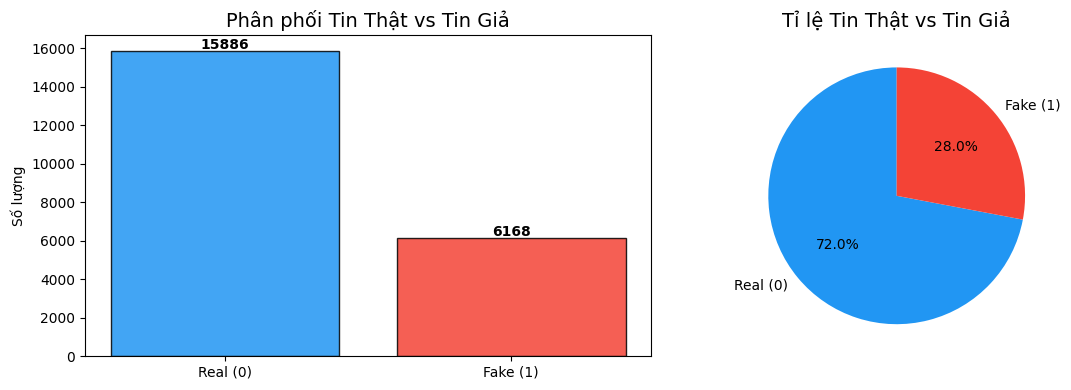

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts = df['label'].value_counts()

axes[0].bar(['Real (0)', 'Fake (1)'], label_counts.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='black')
axes[0].set_title('Phân phối Tin Thật vs Tin Giả', fontsize=14)
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=['Real (0)', 'Fake (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Tỉ lệ Tin Thật vs Tin Giả', fontsize=14)

plt.tight_layout()
plt.show()

## 5. Tiền xử lý dữ liệu

In [ ]:
df.drop('Unnamed: 0', axis=1, errors='ignore', inplace=True)
df.dropna(subset=['title', 'text'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Kết hợp title + text
df['combined'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

print(f'Dataset sau xử lý: {df.shape}')
df.head(3)

Dataset sau xử lý: (22054, 16)


,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title,combined
0,Special Report: 'Treacherous shenanigans' - Th...,HARARE (Reuters) - Inside State House in Harar...,0,en,341,0.029374,79,0.357143,"['special', 'report', 'treacherous', 'shenanig...","['rare', 'renter', 'inside', 'state', 'house',...",81,14775,14856,"['special', 'report', 'treacherous', 'shenanig...",Special Report: 'Treacherous shenanigans' - Th...,Special Report: 'Treacherous shenanigans' - Th...
1,"Warren Buffett, in Annual Letter, Offers Hymn ...","Warren E. Buffett, the billionaire investor, o...",0,en,82,0.020506,47,0.118182,"['warren', 'buffet', 'annual', 'letter', 'offe...","['warren', 'e', 'buffet', 'millionaire', 'inve...",82,3755,3837,"['warren', 'buffet', 'annual', 'letter', 'offe...","Warren Buffett, in Annual Letter, Offers Hymn ...","Warren Buffett, in Annual Letter, Offers Hymn ..."
2,Exclusive: GOP campaigns plot revolt against RNC,"Killing Obama administration rules, dismantlin...",0,ca,3,0.025641,0,0.000000,[],"['kill', 'drama', 'administration', 'rule', 'd...",48,117,165,"[]['kill', 'drama', 'administration', 'rule', ...",Exclusive: GOP campaigns plot revolt against R...,Exclusive: GOP campaigns plot revolt against R...


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Làm sạch và chuẩn hoá văn bản tiếng Anh."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # Xóa URL
    text = re.sub(r'<.*?>', '', text)                       # Xóa HTML
    text = re.sub(r'[^a-z\s]', '', text)                   # Xóa số & ký tự đặc biệt
    words = [lemmatizer.lemmatize(w) for w in text.split()
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print('Đang làm sạch văn bản... (khoảng 2–5 phút)')
df['cleaned_text'] = df['combined'].apply(clean_text)
print('Hoàn thành!')
print(f'\nVí dụ gốc     : {df["combined"].iloc[0][:150]}')
print(f'Ví dụ đã sạch  : {df["cleaned_text"].iloc[0][:150]}')

Đang làm sạch văn bản... (khoảng 2–5 phút)
Hoàn thành!

Ví dụ gốc     : Special Report: 'Treacherous shenanigans' - The inside story of Mugabe's downfall HARARE (Reuters) - Inside State House in Harare, Robert Mugabe was i
Ví dụ đã sạch  : special report treacherous shenanigan inside story mugabes downfall harare reuters inside state house harare robert mugabe tightest spot year rule tan


## 6. Chia tập dữ liệu – Train / Validation / Test



In [ ]:
X = df['cleaned_text']
y = df['label']

# ── Bước 1: 70% train | 30% temp (val + test) ──────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ── Bước 2: chia temp thành 50/50 → val = 15%, test = 15% ─────────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

total = len(X)
print('\n' + '=' * 55)
print('📊 THỐNG KÊ DATASET CHUNG')
print('=' * 55)
print(f'  Tổng mẫu         : {total:,}')
print(f'  Tin thật (0)     : {(y==0).sum():,}  ({(y==0).sum()/total*100:.1f}%)')
print(f'  Tin giả  (1)     : {(y==1).sum():,}  ({(y==1).sum()/total*100:.1f}%)')
print('=' * 55)
print('✅ Dataset sẵn sàng cho cả 4 mô hình!')
print('\n' + '=' * 55)
print('✂️  CHIA TẬP (70% Train | 15% Val | 15% Test)')
print('=' * 55)
print(f'  Train : {len(X_train):,} mẫu ({len(X_train)/total*100:.1f}%)')
print(f'  Val   : {len(X_val):,} mẫu ({len(X_val)/total*100:.1f}%)')
print(f'  Test  : {len(X_test):,} mẫu ({len(X_test)/total*100:.1f}%)')
print('=' * 55)
print(f'  y_train : {dict(sorted(y_train.value_counts().to_dict().items()))}')
print(f'  y_val   : {dict(sorted(y_val.value_counts().to_dict().items()))}')
print(f'  y_test  : {dict(sorted(y_test.value_counts().to_dict().items()))}')
print('=' * 55)


📊 THỐNG KÊ DATASET CHUNG
  Tổng mẫu         : 22,054
  Tin thật (0)     : 15,886  (72.0%)
  Tin giả  (1)     : 6,168  (28.0%)
✅ Dataset sẵn sàng cho cả 4 mô hình!

✂️  CHIA TẬP (70% Train | 15% Val | 15% Test)
  Train : 15,437 mẫu (70.0%)
  Val   : 3,308 mẫu (15.0%)
  Test  : 3,309 mẫu (15.0%)
  y_train : {0: 11120, 1: 4317}
  y_val   : {0: 2383, 1: 925}
  y_test  : {0: 2383, 1: 926}


## 7. Trích xuất đặc trưng TF-IDF (cho Random Forest & SVM)

In [ ]:
print('Đang tạo TF-IDF features...')
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

# Fit CHỈ trên train, transform cả 3 tập
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF (train) : {X_train_tfidf.shape}')
print(f'TF-IDF (val)   : {X_val_tfidf.shape}')
print(f'TF-IDF (test)  : {X_test_tfidf.shape}')

Đang tạo TF-IDF features...
TF-IDF (train) : (15437, 50000)
TF-IDF (val)   : (3308, 50000)
TF-IDF (test)  : (3309, 50000)


---
## Random Forest

In [ ]:
print('=' * 60)
print('MÔ HÌNH 1: RANDOM FOREST')
print('=' * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
print('Đang huấn luyện Random Forest...')
rf_model.fit(X_train_tfidf, y_train)
print('Hoàn thành!')

MÔ HÌNH 1: RANDOM FOREST
Đang huấn luyện Random Forest...
Hoàn thành!



📊 KẾT QUẢ RANDOM FOREST (Test Set):
  Accuracy : 0.9181  (91.81%)
  Log Loss : 0.2697

  Classification Report:
              precision    recall  f1-score   support

        Real       0.91      0.99      0.95      2383
        Fake       0.96      0.74      0.83       926

    accuracy                           0.92      3309
   macro avg       0.93      0.86      0.89      3309
weighted avg       0.92      0.92      0.91      3309



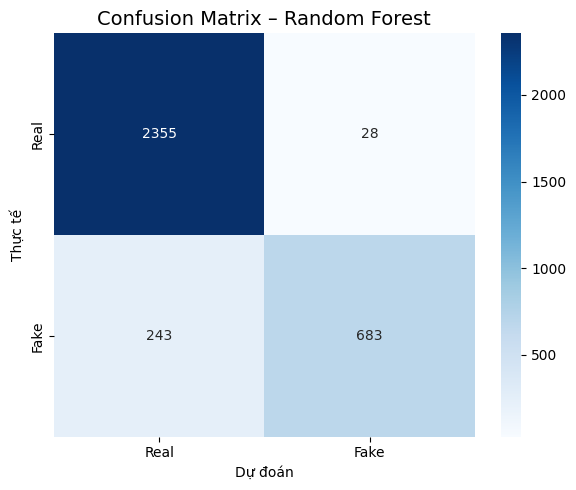

In [ ]:
# Đánh giá trên tập TEST
y_pred_rf = rf_model.predict(X_test_tfidf)
y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_loss = log_loss(y_test, y_prob_rf)

print(f'\n📊 KẾT QUẢ RANDOM FOREST (Test Set):')
print(f'  Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'  Log Loss : {rf_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Real', 'Fake']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – Random Forest', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()

---
## MÔ HÌNH 2: SVM (Support Vector Machine)

In [ ]:
print('=' * 60)
print('MÔ HÌNH 2: SVM (Support Vector Machine)')
print('=' * 60)

svm_base  = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)  # thêm predict_proba

print('Đang huấn luyện SVM...')
svm_model.fit(X_train_tfidf, y_train)
print('Hoàn thành!')

MÔ HÌNH 2: SVM (Support Vector Machine)
Đang huấn luyện SVM...
Hoàn thành!



📊 KẾT QUẢ SVM (Test Set):
  Accuracy : 0.9649  (96.49%)
  Log Loss : 0.0967

  Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.98      0.98      2383
        Fake       0.94      0.93      0.94       926

    accuracy                           0.96      3309
   macro avg       0.96      0.95      0.96      3309
weighted avg       0.96      0.96      0.96      3309



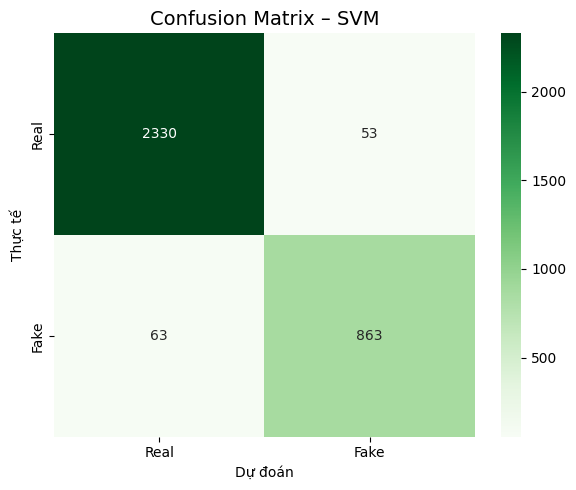

In [ ]:
# Đánh giá trên tập TEST
y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_loss = log_loss(y_test, y_prob_svm)

print(f'\n📊 KẾT QUẢ SVM (Test Set):')
print(f'  Accuracy : {svm_acc:.4f}  ({svm_acc*100:.2f}%)')
print(f'  Log Loss : {svm_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Real', 'Fake']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – SVM', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()

---
## MÔ HÌNH 3: LSTM (Long Short-Term Memory)

In [ ]:
print('=' * 60)
print('MÔ HÌNH 3: LSTM')
print('=' * 60)

VOCAB_SIZE = 30000
MAX_LEN    = 300
EMBED_DIM  = 128
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS     = 10

# Tokenize – fit CHỈ trên train
print('Đang tokenize văn bản...')
tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_val_seq   = tokenizer_lstm.texts_to_sequences(X_val)
X_test_seq  = tokenizer_lstm.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_val_pad   : {X_val_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

MÔ HÌNH 3: LSTM
Đang tokenize văn bản...
X_train_pad : (15437, 300)
X_val_pad   : (3308, 300)
X_test_pad  : (3309, 300)


In [ ]:
def build_lstm_model(vocab_size, embed_dim, lstm_units, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        # XOÁ recurrent_dropout=0.3 ở 2 layer LSTM dưới đây
        Bidirectional(LSTM(lstm_units, dropout=0.3, return_sequences=True)),
        Bidirectional(LSTM(lstm_units // 2, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Khởi tạo mô hình LSTM
lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, MAX_LEN)
lstm_model.summary()

# Huấn luyện LSTM – validation_data dùng X_val_pad (val set thực sự)
print('Đang huấn luyện LSTM...')
early_stop = EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),   # ← val set riêng biệt (15%)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
print('Hoàn thành huấn luyện LSTM!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Đang huấn luyện LSTM...
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.9161 - loss: 0.2037 - val_accuracy: 0.9462 - val_loss: 0.1219
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.9773 - loss: 0.0661 - val_accuracy: 0.9547 - val_loss: 0.1299
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9928 - loss: 0.0243 - val_accuracy: 0.9489 - val_loss: 0.2086
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.9959 - loss: 0.0131 - val_accuracy: 0.9486 - val_loss: 0.1868
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9974 - loss: 0.0078 - val_accuracy: 0.9486 - val_loss: 0.2382
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Hoàn thành huấn luyện LSTM!


52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

📊 KẾT QUẢ LSTM (Test Set):
  Accuracy : 0.9535  (95.35%)
  Log Loss : 0.1369

  Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      2383
        Fake       0.91      0.92      0.92       926

    accuracy                           0.95      3309
   macro avg       0.94      0.94      0.94      3309
weighted avg       0.95      0.95      0.95      3309



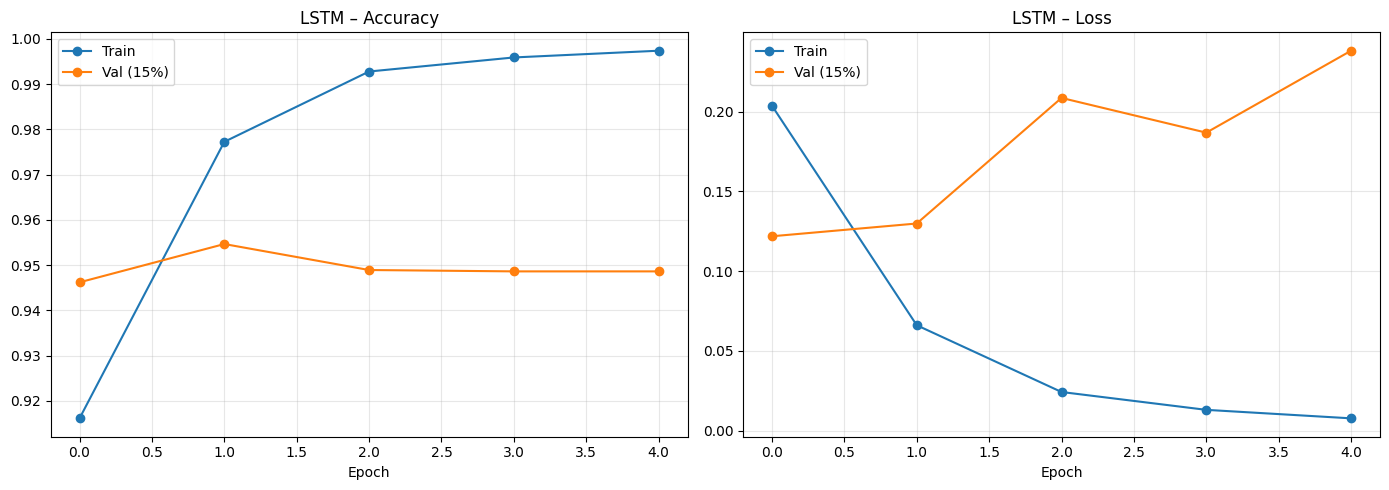

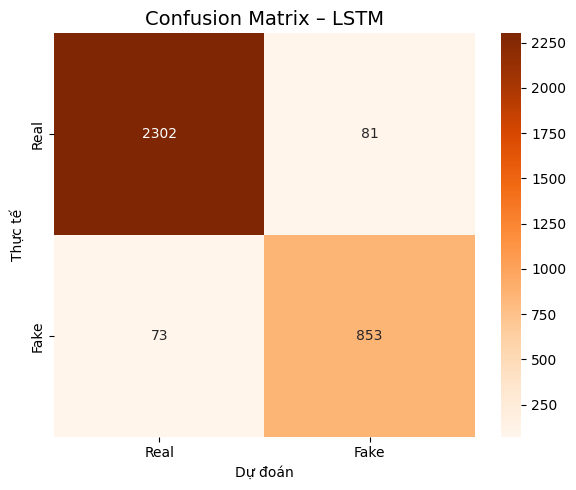

In [ ]:
# Đánh giá LSTM trên tập TEST
y_prob_lstm = lstm_model.predict(X_test_pad, batch_size=BATCH_SIZE).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

lstm_acc  = accuracy_score(y_test, y_pred_lstm)
lstm_loss = log_loss(y_test, y_prob_lstm)

print(f'\n📊 KẾT QUẢ LSTM (Test Set):')
print(f'  Accuracy : {lstm_acc:.4f}  ({lstm_acc*100:.2f}%)')
print(f'  Log Loss : {lstm_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_lstm, target_names=['Real', 'Fake']))

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val (15%)', marker='o')
axes[0].set_title('LSTM – Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Val (15%)', marker='o')
axes[1].set_title('LSTM – Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – LSTM', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()

---
## MÔ HÌNH 4: BERT (bert-base-uncased)

> ⚠️ **Bật GPU trước:** `Runtime → Change runtime type → T4 GPU`

In [ ]:
import torch

print('=' * 60)
print('MÔ HÌNH 4: BERT')
print('=' * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ Không có GPU – BERT sẽ rất chậm!')

MÔ HÌNH 4: BERT
Device: cuda
GPU: Tesla T4


In [ ]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH      = 16
BERT_EPOCHS     = 3
BERT_LR         = 2e-5

# Dùng raw text để BERT khai thác ngữ cảnh tốt hơn
X_train_bert = df.loc[X_train.index, 'combined'].values
X_val_bert   = df.loc[X_val.index,   'combined'].values
X_test_bert  = df.loc[X_test.index,  'combined'].values
y_train_bert = y_train.values
y_val_bert   = y_val.values
y_test_bert  = y_test.values

print('Đang tải BERT tokenizer...')
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print('Tải xong!')

Đang tải BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tải xong!


In [ ]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

# 3 DataLoader: train / val / test
train_ds = NewsDataset(X_train_bert, y_train_bert, bert_tokenizer, BERT_MAX_LEN)
val_ds   = NewsDataset(X_val_bert,   y_val_bert,   bert_tokenizer, BERT_MAX_LEN)
test_ds  = NewsDataset(X_test_bert,  y_test_bert,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BERT_BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH, shuffle=False)

print(f'Số batch train : {len(train_loader):,}')
print(f'Số batch val   : {len(val_loader):,}')
print(f'Số batch test  : {len(test_loader):,}')

Số batch train : 965
Số batch val   : 207
Số batch test  : 207


In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2)
bert_model = bert_model.to(device)
optimizer_bert = AdamW(bert_model.parameters(), lr=BERT_LR, eps=1e-8)
print('Model BERT đã sẵn sàng!')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model BERT đã sẵn sàng!


In [ ]:
def train_bert_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(loader, desc='Training', leave=False):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbls  = batch['label'].to(device)
        optimizer.zero_grad()
        out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss    += out.loss.item()
        total_correct += (torch.argmax(out.logits, 1) == lbls).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_bert(model, loader, device):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss    += out.loss.item()
            probs = torch.softmax(out.logits, 1)[:, 1]
            preds = torch.argmax(out.logits, 1)
            total_correct += (preds == lbls).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return (total_loss / len(loader),
            total_correct / len(loader.dataset),
            np.array(all_preds), np.array(all_probs), np.array(all_labels))

In [ ]:
# Huấn luyện BERT – val_loader dùng val set (15%)
print(f'Bắt đầu huấn luyện BERT ({BERT_EPOCHS} epochs)...')
hist_bert = {'tr_loss':[], 'tr_acc':[], 'val_loss':[], 'val_acc':[]}

for ep in range(BERT_EPOCHS):
    print(f'\n--- Epoch {ep+1}/{BERT_EPOCHS} ---')
    tl, ta = train_bert_epoch(bert_model, train_loader, optimizer_bert, device)
    vl, va, _, _, _ = eval_bert(bert_model, val_loader, device)
    hist_bert['tr_loss'].append(tl);  hist_bert['tr_acc'].append(ta)
    hist_bert['val_loss'].append(vl); hist_bert['val_acc'].append(va)
    print(f'  Train → Loss: {tl:.4f} | Acc: {ta:.4f}')
    print(f'  Val   → Loss: {vl:.4f} | Acc: {va:.4f}')

print('\n✅ Hoàn thành huấn luyện BERT!')

Bắt đầu huấn luyện BERT (3 epochs)...

--- Epoch 1/3 ---


  Train → Loss: 0.0878 | Acc: 0.9706
  Val   → Loss: 0.0597 | Acc: 0.9810

--- Epoch 2/3 ---


  Train → Loss: 0.0194 | Acc: 0.9949
  Val   → Loss: 0.1080 | Acc: 0.9807

--- Epoch 3/3 ---


  Train → Loss: 0.0092 | Acc: 0.9979
  Val   → Loss: 0.1017 | Acc: 0.9822

✅ Hoàn thành huấn luyện BERT!



📊 KẾT QUẢ BERT (Test Set):
  Accuracy : 0.9843  (98.43%)
  Log Loss : 0.0912

  Classification Report:
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      2383
        Fake       0.99      0.95      0.97       926

    accuracy                           0.98      3309
   macro avg       0.99      0.97      0.98      3309
weighted avg       0.98      0.98      0.98      3309



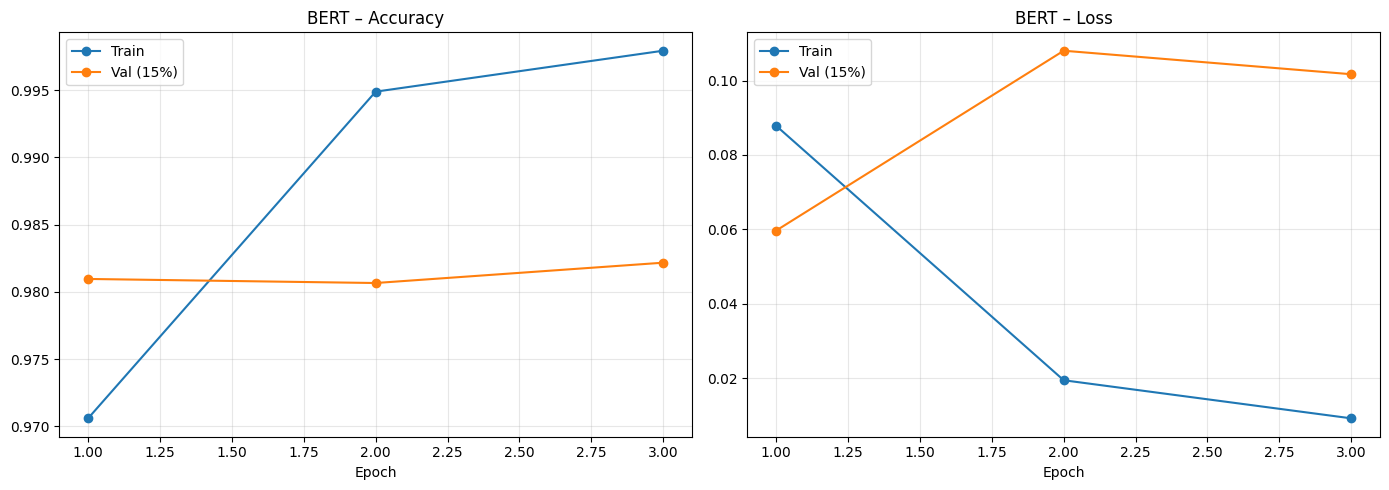

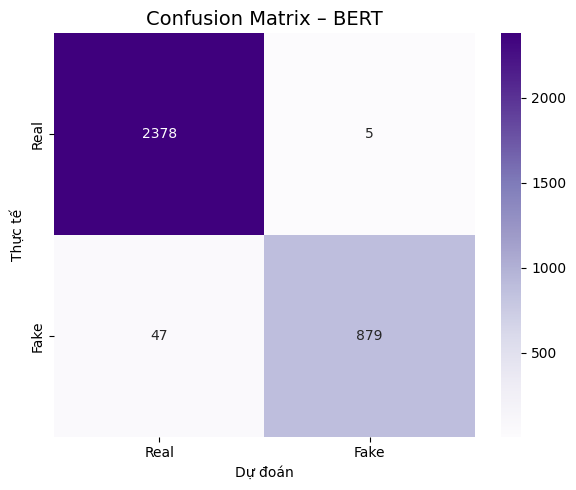

In [ ]:
# Đánh giá BERT trên tập TEST
_, _, y_pred_bert, y_prob_bert, y_true_bert = eval_bert(
    bert_model, test_loader, device)

bert_acc  = accuracy_score(y_true_bert, y_pred_bert)
bert_loss = log_loss(y_true_bert, y_prob_bert)

print(f'\n📊 KẾT QUẢ BERT (Test Set):')
print(f'  Accuracy : {bert_acc:.4f}  ({bert_acc*100:.2f}%)')
print(f'  Log Loss : {bert_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_true_bert, y_pred_bert, target_names=['Real', 'Fake']))

# Learning curves BERT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range = range(1, BERT_EPOCHS + 1)
axes[0].plot(ep_range, hist_bert['tr_acc'],  label='Train', marker='o')
axes[0].plot(ep_range, hist_bert['val_acc'], label='Val (15%)', marker='o')
axes[0].set_title('BERT – Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, hist_bert['tr_loss'],  label='Train', marker='o')
axes[1].plot(ep_range, hist_bert['val_loss'], label='Val (15%)', marker='o')
axes[1].set_title('BERT – Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – BERT', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()

---
## 8. So sánh hiệu suất các mô hình (trên Test Set)

In [ ]:
models  = ['Random Forest', 'SVM', 'LSTM', 'BERT']
accs    = [rf_acc, svm_acc, lstm_acc, bert_acc]
losses  = [rf_loss, svm_loss, lstm_loss, bert_loss]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

results_df = pd.DataFrame({
    'Mô hình'      : models,
    'Accuracy (%)'  : [f'{a*100:.2f}%' for a in accs],
    'Log Loss'      : [f'{l:.4f}' for l in losses]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
results_df.index += 1

print('\n' + '=' * 50)
print('   BẢNG SO SÁNH HIỆU SUẤT (Test Set 15%)')
print('=' * 50)
print(results_df.to_string())
print('=' * 50)


   BẢNG SO SÁNH HIỆU SUẤT (Test Set 15%)
         Mô hình Accuracy (%) Log Loss
1           BERT       98.43%   0.0912
2            SVM       96.49%   0.0967
3           LSTM       95.35%   0.1369
4  Random Forest       91.81%   0.2697


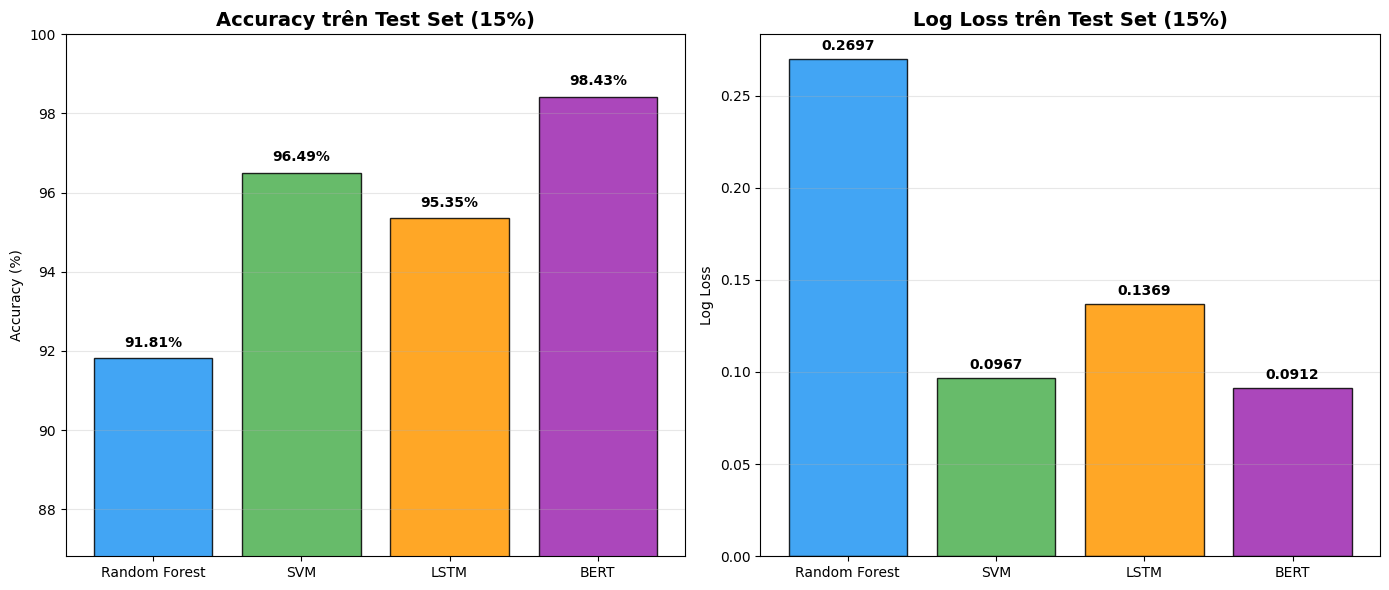

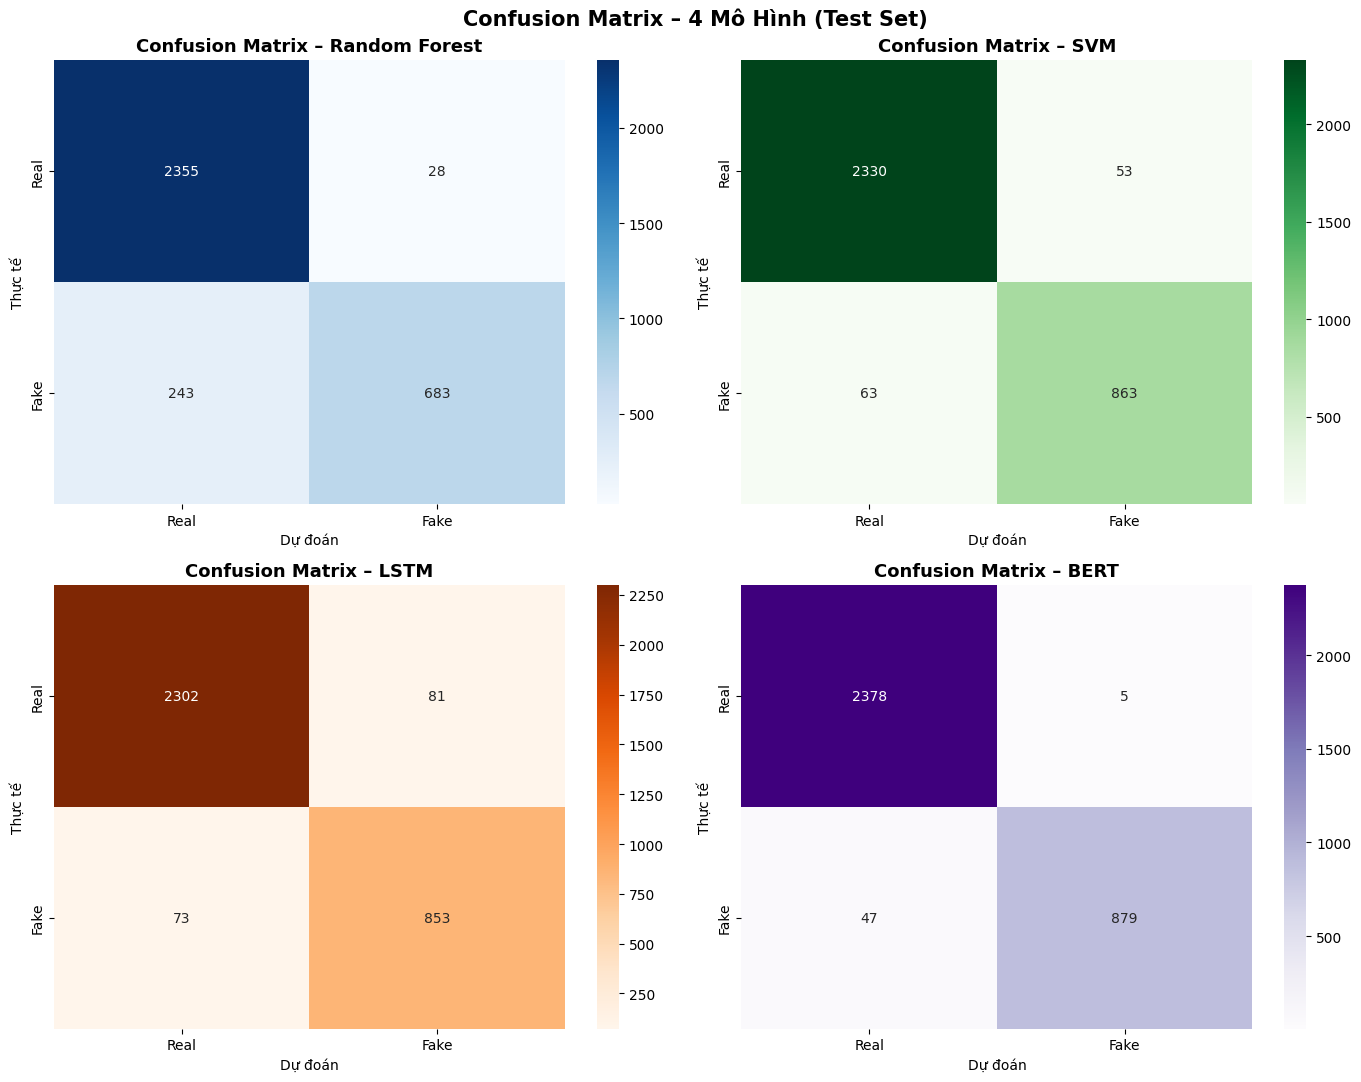

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
bars1 = axes[0].bar(models, [a*100 for a in accs],
                    color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Accuracy trên Test Set (15%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(accs)*100 - 5, 100])
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc*100:.2f}%', ha='center', fontweight='bold')

# Log Loss
bars2 = axes[1].bar(models, losses, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Log Loss trên Test Set (15%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Loss')
axes[1].grid(axis='y', alpha=0.3)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{loss:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
cms   = [cm_rf, cm_svm, cm_lstm, cm_bert]
titls = ['Random Forest', 'SVM', 'LSTM', 'BERT']
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']
for ax, cm, t, c in zip(axes, cms, titls, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=c, ax=ax,
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    ax.set_title(f'Confusion Matrix – {t}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Thực tế'); ax.set_xlabel('Dự đoán')
plt.suptitle('Confusion Matrix – 4 Mô Hình (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Lưu mô hình (tuỳ chọn)

In [ ]:
import pickle, os, shutil
from google.colab import files

print("\n" + "="*55)
print("💾 LƯU MÔ HÌNH VÀO GOOGLE DRIVE")
print("="*55)

# Tạo thư mục trên Google Drive
drive_models_dir = '/content/drive/MyDrive/FakeNews_Models_English'
os.makedirs(drive_models_dir, exist_ok=True)
print(f"\n📁 Thư mục: {drive_models_dir}")

# 1. Lưu TF-IDF
print("\n1️⃣  Lưu TF-IDF Vectorizer...")
with open(f'{drive_models_dir}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("   ✅ tfidf_vectorizer.pkl")

# 2. Lưu Random Forest
print("\n2️⃣  Lưu Random Forest...")
with open(f'{drive_models_dir}/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("   ✅ random_forest.pkl")

# 3. Lưu SVM
print("\n3️⃣  Lưu SVM model...")
with open(f'{drive_models_dir}/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("   ✅ svm_model.pkl")

# 4. Lưu LSTM
print("\n4️⃣  Lưu LSTM model...")
lstm_model.save(f'{drive_models_dir}/lstm_model.h5')
with open(f'{drive_models_dir}/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
print("   ✅ lstm_model.h5")
print("   ✅ lstm_tokenizer.pkl")

# 5. Lưu BERT
print("\n5️⃣  Lưu BERT model...")
bert_model.save_pretrained(f'{drive_models_dir}/bert_model')
bert_tokenizer.save_pretrained(f'{drive_models_dir}/bert_tokenizer')
print("   ✅ bert_model/ (folder)")
print("   ✅ bert_tokenizer/ (folder)")

# 6. Tạo README
print("\n6️⃣  Tạo README...")
readme = """# FAKE NEWS DETECTION MODELS (ENGLISH - 22K)

## Dataset
- Source: WELFake Dataset (English)
- Total: 22,054 samples (balanced with Vietnamese dataset)
- Real (0): 15,886 (72%)
- Fake (1): 6,168 (28%)
- Split: Train 70% | Val 15% | Test 15%

## Models
1. Random Forest + TF-IDF
2. SVM + TF-IDF
3. LSTM (Keras)
4. BERT (bert-base-uncased)

## Files
- tfidf_vectorizer.pkl
- random_forest.pkl
- svm_model.pkl
- lstm_model.h5
- lstm_tokenizer.pkl
- bert_model/
- bert_tokenizer/
"""
with open(f'{drive_models_dir}/README.md', 'w') as f:
    f.write(readme)
print("   ✅ README.md")

print("\n" + "="*55)
print("🎉 HOÀN TẤT!")
print("="*55)
print(f"\n📁 Models đã lưu vào: {drive_models_dir}")
print("\n✨ Truy cập Google Drive để lấy models!")
print("="*55)


💾 LƯU MÔ HÌNH VÀO GOOGLE DRIVE

📁 Thư mục: /content/drive/MyDrive/FakeNews_Models_English

1️⃣  Lưu TF-IDF Vectorizer...
   ✅ tfidf_vectorizer.pkl

2️⃣  Lưu Random Forest...


   ✅ random_forest.pkl

3️⃣  Lưu SVM model...
   ✅ svm_model.pkl

4️⃣  Lưu LSTM model...
   ✅ lstm_model.h5
   ✅ lstm_tokenizer.pkl

5️⃣  Lưu BERT model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ bert_model/ (folder)
   ✅ bert_tokenizer/ (folder)

6️⃣  Tạo README...
   ✅ README.md

🎉 HOÀN TẤT!

📁 Models đã lưu vào: /content/drive/MyDrive/FakeNews_Models_English

✨ Truy cập Google Drive để lấy models!


## 10. Tóm tắt kết quả

In [ ]:
print('\n' + '=' * 65)
print('         TỔNG KẾT – HỆ THỐNG PHÁT HIỆN TIN GIẢ')
print('=' * 65)
print(f'  Dataset : WELFake (tiếng Anh)')

print(f'  {"Mô hình":<20} {"Accuracy":>12} {"Log Loss":>12}')
print('-' * 65)
for m, a, l in zip(models, accs, losses):
    print(f'  {m:<20} {a*100:>10.2f}% {l:>12.4f}')
print('-' * 65)
best = models[int(np.argmax(accs))]
print(f'  🏆 Tốt nhất: {best}  →  {max(accs)*100:.2f}%')
print('=' * 65)


         TỔNG KẾT – HỆ THỐNG PHÁT HIỆN TIN GIẢ
  Dataset : WELFake (tiếng Anh)
  Mô hình                  Accuracy     Log Loss
-----------------------------------------------------------------
  Random Forest             91.81%       0.2697
  SVM                       96.49%       0.0967
  LSTM                      95.35%       0.1369
  BERT                      98.43%       0.0912
-----------------------------------------------------------------
  🏆 Tốt nhất: BERT  →  98.43%
